In [28]:
import numpy as np
import matplotlib.pyplot as plt
from pulp import *
from scipy.spatial.distance import cdist
from matplotlib.patches import Rectangle


In [ ]:
# Generación del escenario de usuarios
def escenario(m=100, #Número de usuarios
              n=50, #Número de médicos
              dt=10, #Intervalo de tiempo
              K=144,  #Número de intervalos de Tiempo
              velocidad=30, #Velocidad de los carros médicos en unidades de km/hora
              L=30 #Dimensión de la región aleatoria de usuarios
            ): 
    r=np.random.uniform(low=0, high=L, size=(m,2)) #Posiciones de los usuarios
    distancias = cdist(r, r)
    #Ya calculada la distancia, convertimos a r en un diccionario
    r={(i+1):r[i] for i in range(len(r))}
    delta=distancias/velocidad*60 #Matriz de distancias en minutos
    delta=np.ceil(delta/dt) #Matriz de distancias en intervalos de tiempo
    delta={(i+1,j+1):delta[i,j] for i in range(0,m) for j in range(0,m)}

    H=12 #Horas de un turno de un médico
    beta=int(H*60/dt) #Numero máximo de turnos seguidos por un médico, 
    Cmed=25000*H
    costo=distancias*600 #Costo de $600 por km de recorrido
    costo={(i+1,j+1):costo[i,j] for i in range(0,m) for j in range(0,m)}
    #Agregaremos los nodos de origen S y destino T, por ahora con valores 0 en tiempo y costo
    for i in range(1,m+1):
        delta['S',i]=0
        delta[i,'T']=0
        costo['S',i]=0
        costo[i,'T']=0
    #Generación de parámetros de servicio de los pacientes
    a={i:np.random.randint(low=1, high=K-10) for i in range(1,m+1)} #Tiempo de llegada de los usuarios
    b={}
    c={}
    for i in range(1,m+1):
        ventana=np.random.randint(low=4, high=20) #Duración de la ventana de servicio
        ventana=min(144-a[i]-1, ventana)
        b[i]=a[i]+ventana+1
        duracion=np.random.randint(low=1, high=b[i]-a[i])
        c[i]=duracion

    #Parámetros auxiliares para construir las ecuaciones
    alfa={}
    tau={i:[] for i in range(1,m+1)}
    for i in range(1,m+1):
        for k in range(1, K+1):
            if(k>=a[i] and k<=b[i]-c[i]+1):
                alfa[i,k]=1
                tau[i].append(k)
            else:
                alfa[i,k]=0
    return {'m':m, 'n':n, 'dt':dt, 'K':K, 'velocidad':velocidad, 'L':L, 'r':r, 'delta':delta, 
            'beta':beta, 'Cmed':Cmed, 'costo':costo, 'a':a, 'b':b, 'c':c, 'tau':tau, 'alfa':alfa }
S=escenario()

def partir_escenario_posicion(S, n, dibujar=False):
    #Vamos a partir los escenarios de acuerdo con el número de puntos que tengamos. Vamos a suponer por ahora que n va entre 1 y 4, separando por medio de rectas horizontales y verticales
    if(n==1):
        return [S]
    if(n>1):
        ri=np.array(list(S['r'].values()))
        c=np.mean(ri, axis=0)
        ni=len(S['r'])/n-1 #Número de elementos por grupo
        if(int(ni)==ni):
            ni=ni-1
        else:
            ni=int(ni)+1
        if(dibujar):
            print('c=',c)
            plt.plot(c[0], c[1], 'xr')
            print('Ni: ',ni)
        grupos=[]
        tmp=[]
        usados=[]
        for th in np.linspace(0,2*np.pi,360):
            u=np.array([np.cos(th), np.sin(th)])
            if(dibujar):
                plt.plot([c[0], c[0]+u[0]*10], [c[1], c[1]+u[1]*10], '-g')
            for k,v in S['r'].items():
                ang=np.arccos(np.dot(v-c,u)/np.linalg.norm(v-c))
                #fi= np.mod(np.arctan2((v-c)[1], (v-c)[0]), 2*np.pi)
                #dif=np.rad2deg(np.abs(th-fi))
                if(ang<np.deg2rad(1.0) and ang>=0 and k not in usados):# and dif<5):
                    #print(f'Indice usuario: {k}, posición {v}, ángulo de búsqueda: {np.rad2deg(th)}, \nAngulo de diferencia: {np.rad2deg(ang)}, Diferencia absoluta: {dif}, Unitario: {u}\n')
                    tmp.append(k)
                    usados.append(k)
                if(len(tmp)>ni):
                    grupos.append(tmp)
                    #for ind in tmp: 
                    #    plt.plot(S['r'][ind][0],S['r'][ind][1],'ob')
                    #    plt.text(S['r'][ind][0],S['r'][ind][1], str(ind)+','+str(len(grupos)))
                    tmp=[]
                    #print(np.rad2deg(th), [gi for gi in grupos])
        if(len(tmp)>0):
            grupos.append(tmp)
        if(dibujar):
            plt.axis('equal')
            plt.grid()
        #print(grupos)
    #Para cada grupo se requiere organizar la siguiente información: 
    #'m':m, 'n':n, 'dt':dt, 'K':K, 'velocidad':velocidad, 'L':L, 'r':r, 'delta':delta, 'a':a, 'b':b, 'c':c, 'tau':tau 
    Sout=[]
    for gr in grupos:
        tmp={'m':len(gr), 'n':S['n'], 'dt':S['dt'], 'K':S['K'], 'velocidad':S['velocidad'], 'L':S['L'], 
             'beta':S['beta'], 'Cmed':S['Cmed'], 'costo':S['costo'],
                'r':[], 'delta':{}, 'a':{}, 'b':{}, 'c':{}, 'tau':{} }
        tmp['r']={ind:S['r'][ind] for ind in gr}
        tmp['delta']={(i,j):S['delta'][i,j] for i in gr for j in gr}
        tmp['a']={ind:S['a'][ind] for ind in gr}
        tmp['b']={ind:S['b'][ind] for ind in gr}
        tmp['c']={ind:S['c'][ind] for ind in gr}
        tmp['alfa']={k:v for k,v in S['alfa'].items() if k[0] in gr}
        tmp['tau']={ind:S['tau'][ind] for ind in gr}
                        
        Sout.append(tmp)
    return Sout                        

def partir_escenario_clusters(S, n, dibujar=False, max_iter=50, random_state=None):
    from scipy.optimize import linear_sum_assignment

    if n < 1:
        raise ValueError('n debe ser mayor o igual a 1')
    if n == 1:
        return [S]
    if n > len(S['r']):
        raise ValueError('n no puede ser mayor que el numero de usuarios')

    ids = np.array(list(S['r'].keys()))
    puntos = np.array(list(S['r'].values()))
    m = len(ids)

    capacidades = np.full(n, m // n, dtype=int)
    capacidades[:m % n] += 1

    rng = np.random.default_rng(random_state)
    centroides = [puntos[rng.integers(m)]]
    while len(centroides) < n:
        dist_min = cdist(puntos, np.array(centroides)).min(axis=1)
        siguiente = np.argmax(dist_min)
        centroides.append(puntos[siguiente])
    centroides = np.array(centroides, dtype=float)

    asignacion = None
    for _ in range(max_iter):
        centroides_expandidos = np.repeat(centroides, capacidades, axis=0)
        dueno = np.concatenate([np.full(cap, i, dtype=int) for i, cap in enumerate(capacidades)])
        costo_asignacion = cdist(puntos, centroides_expandidos)
        filas, cols = linear_sum_assignment(costo_asignacion)
        nueva_asignacion = np.empty(m, dtype=int)
        nueva_asignacion[filas] = dueno[cols]

        nuevos_centroides = centroides.copy()
        for i in range(n):
            miembros = puntos[nueva_asignacion == i]
            if len(miembros) > 0:
                nuevos_centroides[i] = miembros.mean(axis=0)

        if asignacion is not None and np.array_equal(nueva_asignacion, asignacion):
            asignacion = nueva_asignacion
            centroides = nuevos_centroides
            break

        asignacion = nueva_asignacion
        centroides = nuevos_centroides

    grupos = []
    for i in range(n):
        grupo_ids = ids[asignacion == i].tolist()
        if len(grupo_ids) > 0:
            grupos.append(grupo_ids)

    if dibujar:
        for i, gr in enumerate(grupos):
            ri = np.array([S['r'][ind] for ind in gr])
            plt.plot(ri[:,0], ri[:,1], 'o', label='cluster ' + str(i))
        plt.plot(centroides[:,0], centroides[:,1], 'xk', label='centroides')
        plt.axis('equal')
        plt.grid()
        plt.legend()

    Sout=[]
    for gr in grupos:
        tmp={'m':len(gr), 'n':S['n'], 'dt':S['dt'], 'K':S['K'], 'velocidad':S['velocidad'], 'L':S['L'], 
             'beta':S['beta'], 'Cmed':S['Cmed'], 'costo':S['costo'],
                'r':[], 'delta':{}, 'a':{}, 'b':{}, 'c':{}, 'tau':{} }
        tmp['r']={ind:S['r'][ind] for ind in gr}
        tmp['delta']={(i,j):S['delta'][i,j] for i in gr for j in gr}
        tmp['a']={ind:S['a'][ind] for ind in gr}
        tmp['b']={ind:S['b'][ind] for ind in gr}
        tmp['c']={ind:S['c'][ind] for ind in gr}
        tmp['alfa']={k:v for k,v in S['alfa'].items() if k[0] in gr}
        tmp['tau']={ind:S['tau'][ind] for ind in gr}
        Sout.append(tmp)
    return Sout



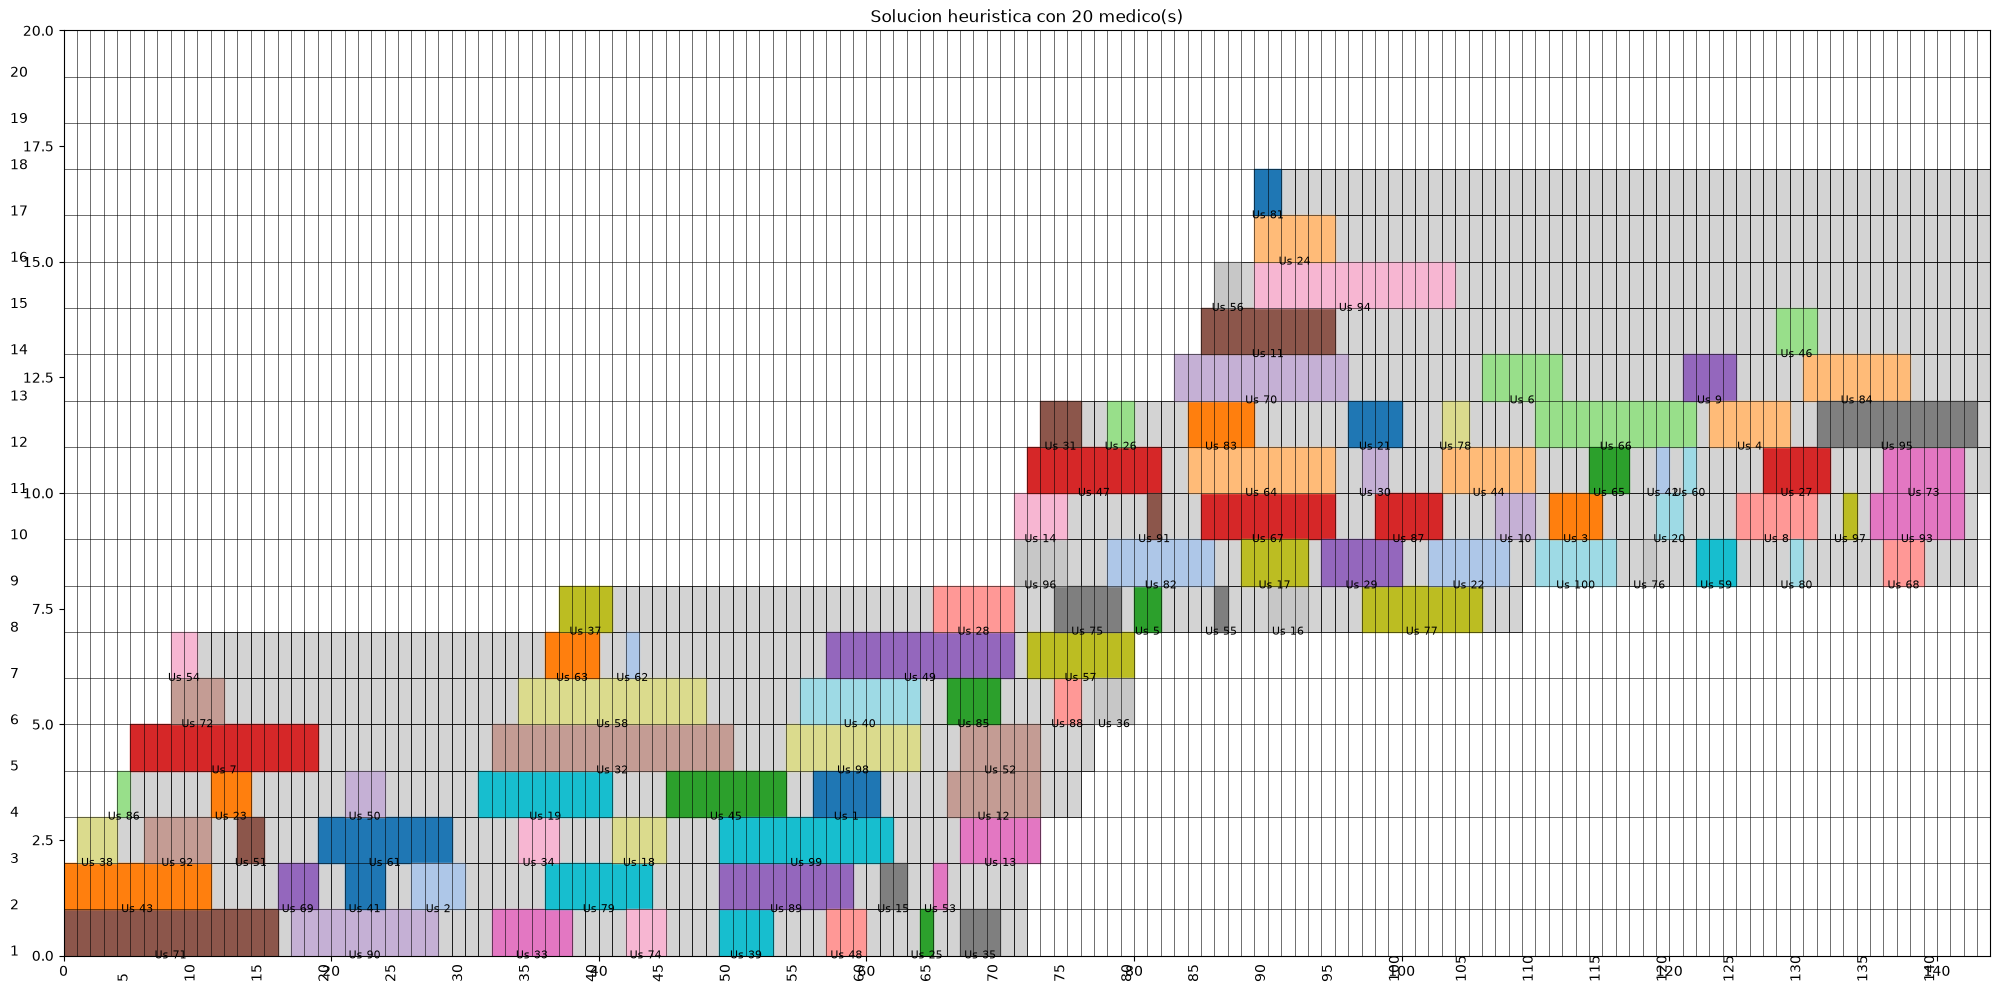

In [30]:
# Solución heurística del problema
def heuristic(S, n, mostrar=False):
    m=S['m']
    #n=S['n']
    K=S['K']
    delta=S['delta']
    a=S['a']
    b=S['b']
    c=S['c']
    tau=S['tau']
    alfa=S['alfa']
    r=S['r']
    beta=S['beta']
    Cmed=S['Cmed']
    costo=S['costo']

    pacientes = sorted(list(r.keys()), key=lambda i: (tau[i][0], len(tau[i]), b[i], i))
    medicos = {j: {'pacientes': [], 'inicio_turno': None, 'fin_turno': None, 'ultimo': None} for j in range(1, n + 1)}
    asignacion = {}

    for i in pacientes:
        asignado = False
        for j in range(1, n + 1):
            info = medicos[j]
            if info['ultimo'] is None:
                inicio_minimo = tau[i][0]
                inicio_turno = None
                anterior = 'S'
            else:
                anterior = info['ultimo']
                inicio_minimo = int(info['fin_turno'] + delta[anterior, i])
                inicio_turno = info['inicio_turno']

            inicio_asignado = None
            for k in tau[i]:
                if k < inicio_minimo:
                    continue
                if inicio_turno is not None and k + c[i] > inicio_turno + beta:
                    continue
                inicio_asignado = int(k)
                break

            if inicio_asignado is None:
                continue

            fin_servicio = int(inicio_asignado + c[i])
            if info['inicio_turno'] is None:
                info['inicio_turno'] = inicio_asignado
            info['fin_turno'] = fin_servicio
            info['ultimo'] = i
            info['pacientes'].append(i)
            asignacion[i] = {
                'medico': j,
                'inicio': inicio_asignado,
                'fin': fin_servicio,
                'anterior': anterior
            }
            asignado = True
            break

        if not asignado:
            resultado = {
                'factible': False,
                'costo': None,
                'medicos_activos': sum(1 for info in medicos.values() if info['pacientes']),
                'asignacion': asignacion,
                'orden_pacientes': pacientes,
                'paciente_no_asignado': i,
                'medicos': medicos
            }
            #print(f'Factible: {resultado["factible"]}')
            #print(f'No fue posible asignar el paciente {i} con {n} medico(s).')
            return resultado

    costo_total = 0.0
    medicos_activos = 0
    for j in range(1, n + 1):
        ruta = medicos[j]['pacientes']
        if not ruta:
            continue
        medicos_activos += 1
        costo_total += Cmed
        anterior = 'S'
        for paciente in ruta:
            costo_total += float(costo[anterior, paciente])
            anterior = paciente
        costo_total += float(costo[anterior, 'T'])

    resultado = {
        'factible': True,
        'costo': costo_total,
        'medicos_activos': medicos_activos,
        'asignacion': asignacion,
        'orden_pacientes': pacientes,
        'medicos': medicos
    }

    #print(f'Factible: {resultado["factible"]}')
    #print(f'Costo: {resultado["costo"]:.2f}')
    #print(f'Medicos activos: {resultado["medicos_activos"]}')
    return resultado

def dibujar_solucion(S, resultado):
    m=S['m']
    #n=S['n']
    K=S['K']
    delta=S['delta']
    a=S['a']
    b=S['b']
    c=S['c']
    tau=S['tau']
    alfa=S['alfa']
    r=S['r']
    beta=S['beta']
    Cmed=S['Cmed']
    costo=S['costo']

    medicos=resultado['medicos']
    n=len(medicos)
    asignacion=resultado['asignacion']
    pacientes=resultado['orden_pacientes']

    cmap = plt.get_cmap('tab20')
    colors = [cmap(i % cmap.N) for i in range(m + 1)]
    plt.figure(figsize=(20, 10))
    ax = plt.gca()
    lw = 0.4

    for j in range(0, n + 1):
        plt.plot([0, K], [j, j], '-k', linewidth=lw)
        if j < n:
            plt.text(-4, j, str(j + 1))
    for k in range(0, K + 1):
        plt.plot([k, k], [0, n], '-k', linewidth=lw)
        if k < K and (k + 1) % 5 == 0:
            plt.text(k, -0.5, str(k + 1), fontsize=10, rotation=90)

    for j in range(1, n + 1):
        info = medicos[j]
        if not info['pacientes']:
            continue
        inicio = info['inicio_turno']
        fin_turno = min(inicio + beta, K + 1)
        for k in range(inicio, fin_turno):
            rect = Rectangle(
                (k - 1, j - 1),
                1,
                1,
                facecolor='lightgray',
                edgecolor='black',
                linewidth=lw
            )
            ax.add_patch(rect)

    for i, info_asig in asignacion.items():
        j = info_asig['medico']
        k = info_asig['inicio']
        for paso in range(c[i]):
            rect = Rectangle(
                (k - 1 + paso, j - 1),
                1,
                1,
                facecolor=colors[i - 1],
                edgecolor=colors[i - 1],
                linewidth=1
            )
            ax.add_patch(rect)
        centro = k - 1 + c[i] / 2
        plt.text(centro, j - 1, f'Us {i}', ha='center', va='center', fontsize=8)

    plt.xlim(0, K)
    plt.ylim(0, max(1, n))
    plt.title(f'Solucion heuristica con {n} medico(s)')
    plt.tight_layout()
    plt.show()
S=escenario()
resultado_heuristico = heuristic(S,20)
dibujar_solucion(S, resultado_heuristico)

In [31]:
L=[1,2,3,4,5]
N=[]
C=[]
tmpN={i:[] for i in L}
tmpC={i:[] for i in L}

for k in range(50): #Vamos a hacer un total de 20 simulaciones
    print('\n------------------------------------------\nCorrida ',k)
    S=escenario()
    for i in L:
        #print('Procediendo con '+str(i)+' particiones')
        scen=partir_escenario_posicion(S, i)
        ni=[]
        ci=[]
        for ind,si in enumerate(scen):
            #print(f'Partición {ind} de {i}')
            num=1
            factible=False
            while(not factible and num<40):
                #print(num,',', end='', sep='')
                res=heuristic(si, num)
                factible=res['factible']
                costo=res['costo']
                nm=res['medicos_activos']
                num+=1
            ni.append(costo)
            ci.append(nm)
        tmpN[i].append(np.sum(ni))
        tmpC[i].append(np.sum(ci))

for i in L:
    N.append(np.mean(tmpN[i]))
    C.append(np.mean(tmpC[i]))


------------------------------------------
Corrida  0
Procediendo con 1 particiones
Procediendo con 2 particiones
Procediendo con 3 particiones
Procediendo con 4 particiones
Procediendo con 5 particiones

------------------------------------------
Corrida  1
Procediendo con 1 particiones
Procediendo con 2 particiones
Procediendo con 3 particiones
Procediendo con 4 particiones
Procediendo con 5 particiones

------------------------------------------
Corrida  2
Procediendo con 1 particiones
Procediendo con 2 particiones
Procediendo con 3 particiones
Procediendo con 4 particiones
Procediendo con 5 particiones

------------------------------------------
Corrida  3
Procediendo con 1 particiones
Procediendo con 2 particiones
Procediendo con 3 particiones
Procediendo con 4 particiones
Procediendo con 5 particiones

------------------------------------------
Corrida  4
Procediendo con 1 particiones
Procediendo con 2 particiones
Procediendo con 3 particiones
Procediendo con 4 particiones
Proce

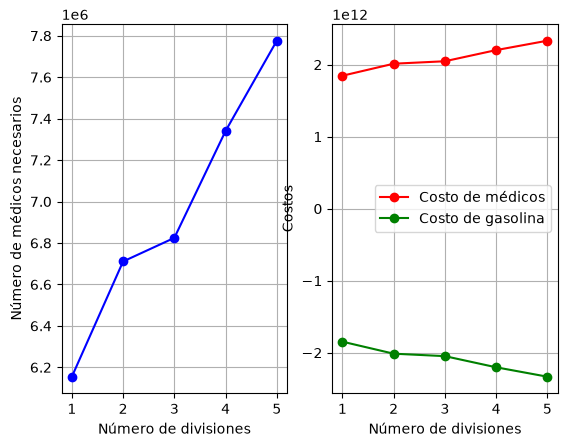

In [32]:
C=np.array(C)
N=np.array(N)
Cm=N*S['Cmed']
Cg=C-Cm
plt.subplot(1,2,1)
plt.plot(L,N,'o-b')
plt.xlabel('Número de divisiones')
plt.ylabel('Número de médicos necesarios')
plt.grid()

plt.subplot(1,2,2)
plt.plot(L,Cm,'o-r', label='Costo de médicos')
plt.plot(L,Cg,'o-g', label='Costo de gasolina')
plt.xlabel('Número de divisiones')
plt.ylabel('Costos')
plt.grid()
plt.legend()
